In [5]:
import numpy as np
import pandas as pd
import os
import glob
import sys
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(".."))
from libs.my_statics import ttest, violin

save_folder = "../figures/vel_MT"
os.makedirs(save_folder, exist_ok=True)

plt.style.use('../libs/my_style.mplstyle')
style_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

def getdf(dir_path):
    df_list = []

    file_list = glob.glob(os.path.join(dir_path, "*.csv"))
    for file_path in file_list:
        file = pd.read_csv(file_path)
        df_list.append(file)

    df_concat = pd.concat(df_list, ignore_index=True)

    only_MT = df_concat[df_concat['TID'] == 1]['v [µm/sec]'].to_numpy()
    MT_move = df_concat[df_concat['TID'] == 2]['v [µm/sec]'].to_numpy()

    plots = [only_MT[~np.isnan(only_MT)], MT_move[~np.isnan(MT_move)]]

    return plots


MC00_1 = getdf(dir_path='/Volumes/My Passport/Sasaki/MTsingleBeads/20240827/cargo_before_after_MT1uM_MC00')
MC00_2 = getdf(dir_path='/Volumes/My Passport/Sasaki/MTsingleBeads/20240926/cargo_before_after_MT1uM_MC00')
MC00_3 = getdf(dir_path='/Volumes/My Passport/Sasaki/MTsingleBeads/20240828/cargo_before')
MC00_4 = getdf(dir_path='/Volumes/My Passport/Sasaki/MTsingleBeads/20241129/cargo_before_after_MT1uM_MC00') 

MC03_1 = getdf(dir_path='/Volumes/My Passport/Sasaki/MTsingleBeads/20240910/cargo_before_after_MT1uM_MC03')
MC03_2 = getdf(dir_path='/Volumes/My Passport/Sasaki/MTsingleBeads/20240910/cargo_before_MT083uM_MC03_1')
MC03_3 = getdf(dir_path='/Volumes/My Passport/Sasaki/MTsingleBeads/20240926/cargo_before_after_MT1uM_MC03')
MC03_4 = getdf(dir_path='/Volumes/My Passport/Sasaki/MTsingleBeads/20241127/cargo_before_after_MT1uM_MC03')


p-value: 9.135500766631503e-08, MTs: 0.41 μm, Transportation: 0.28 μm
p-value: 9.39410998806434e-12, MTs: 0.49 μm, Transportation: 0.35 μm
p-value: 0.029329523537115425, MTs: 0.28 μm, Transportation: 0.26 μm
p-value: 0.0990981249751762, MTs: 0.63 μm, Transportation: 0.61 μm
p-value: 8.193612437193763e-11, MTs exp1: 0.41 μm, MTs exp2: 0.49 μm


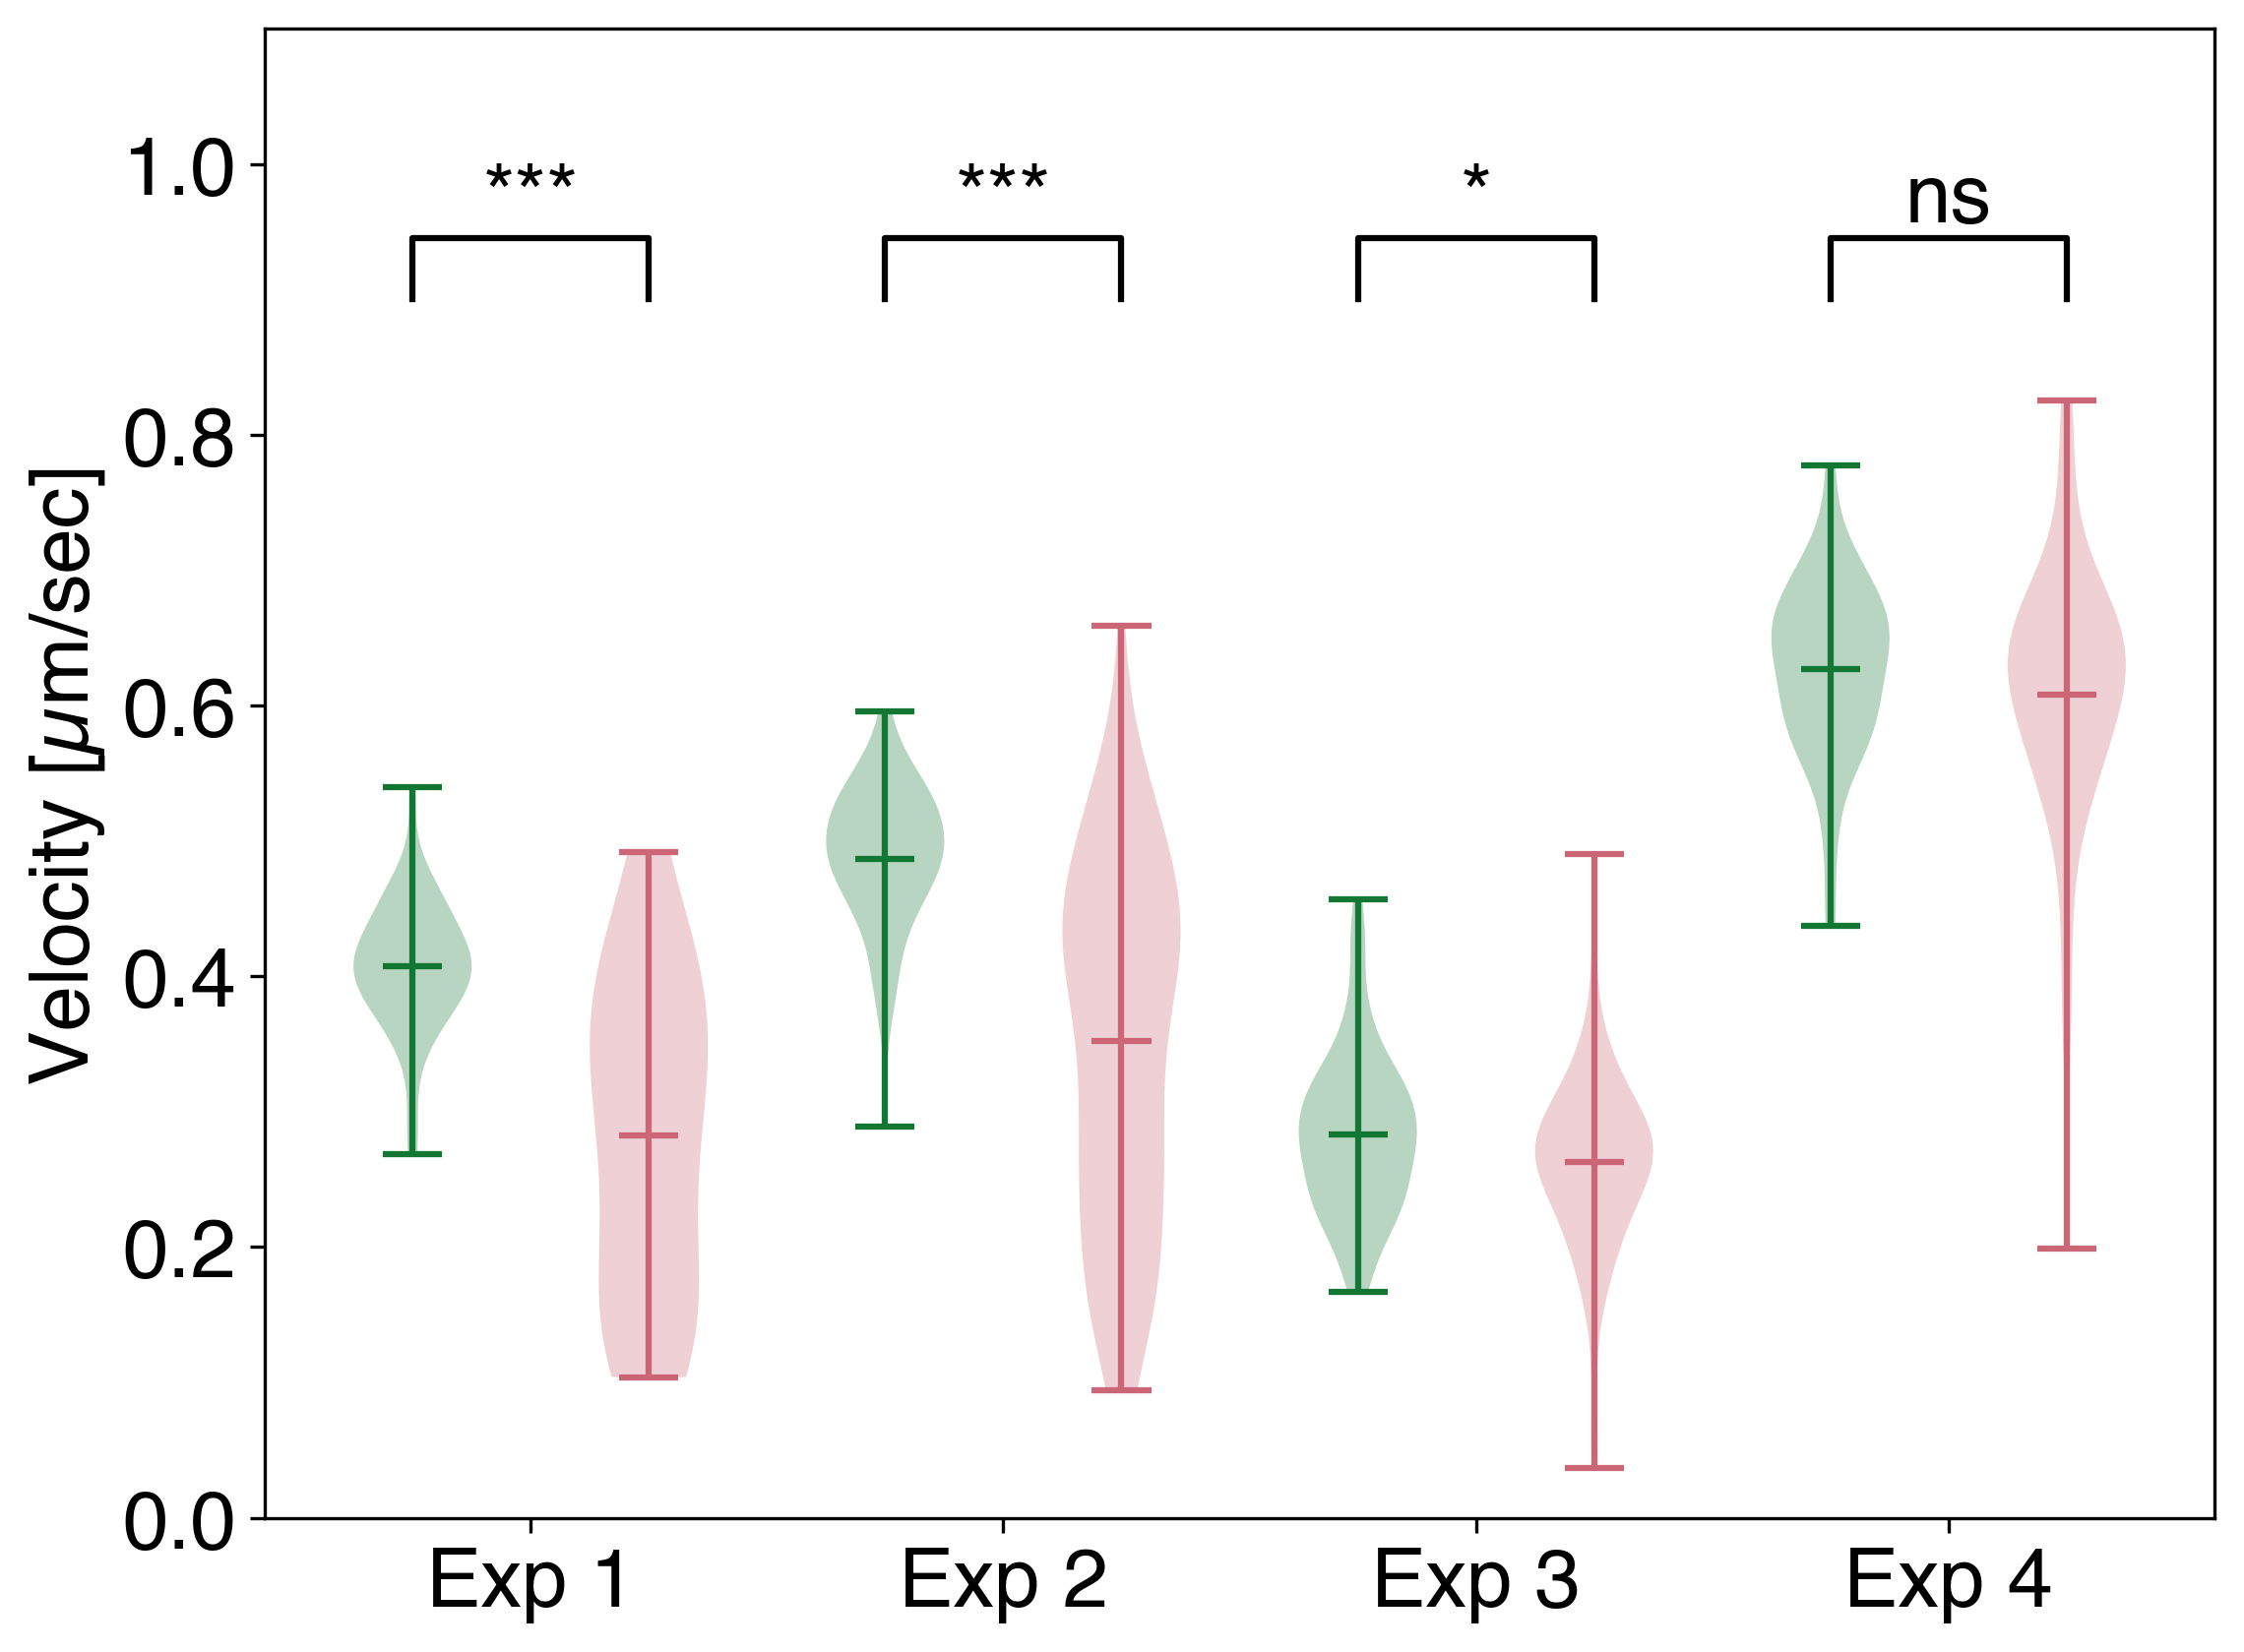

In [6]:
statics00_1, p_value00_1, sig00_1 = ttest(MC00_1[0], MC00_1[1], alternative='greater', nan_policy='omit')
statics00_2, p_value00_2, sig00_2 = ttest(MC00_2[0], MC00_2[1], alternative='greater', nan_policy='omit')
statics00_3, p_value00_3, sig00_3 = ttest(MC00_3[0], MC00_3[1], alternative='greater', nan_policy='omit')
statics00_4, p_value00_4, sig00_4 = ttest(MC00_4[0], MC00_4[1], alternative='greater', nan_policy='omit')

statics_12, p_value_12, sig_12 = ttest(MC00_2[0], MC00_1[0])

fig, ax = plt.subplots()

violin(MC00_1[0], ax, positions=1, color=style_colors[3])
violin(MC00_1[1], ax, positions=2, color=style_colors[0])
violin(MC00_2[0], ax, positions=3, color=style_colors[3])
violin(MC00_2[1], ax, positions=4, color=style_colors[0])
violin(MC00_3[0], ax, positions=5, color=style_colors[3])
violin(MC00_3[1], ax, positions=6, color=style_colors[0])
violin(MC00_4[0], ax, positions=7, color=style_colors[3])
violin(MC00_4[1], ax, positions=8, color=style_colors[0])

y_max = np.max(np.concatenate(MC03_1))
y = 0.9

h = y * 0.05

y_l = [y, y + h, y + h, y]

ax.plot([1, 1, 2, 2], y_l, lw=1.5, c='black')
ax.text(1.5, y + h, sig00_1, ha='center', va='bottom', color='black')

ax.plot([3, 3, 4, 4], y_l, lw=1.5, c='black')
ax.text(3.5, y + h, sig00_2, ha='center', va='bottom', color='black')

ax.plot([5, 5, 6, 6], y_l, lw=1.5, c='black')
ax.text(5.5, y + h, sig00_3, ha='center', va='bottom', color='black')

ax.plot([7, 7, 8, 8], y_l, lw=1.5, c='black')
ax.text(7.5, y + h, sig00_4, ha='center', va='bottom', color='black')

ax.set_ylabel('Velocity [µm/sec]')
ax.set_xticks([1.5, 3.5, 5.5, 7.5])
ax.set_xticklabels(['Exp 1', 'Exp 2', 'Exp 3', 'Exp 4'])
ax.set_ylim(0, 1.1)

print(f'p-value: {p_value00_1}, MTs: {"{:.2f}".format(np.mean(MC00_1[0]))} \u03bcm, Transportation: {"{:.2f}".format(np.mean(MC00_1[1]))} \u03bcm')
print(f'p-value: {p_value00_2}, MTs: {"{:.2f}".format(np.mean(MC00_2[0]))} \u03bcm, Transportation: {"{:.2f}".format(np.mean(MC00_2[1]))} \u03bcm')
print(f'p-value: {p_value00_3}, MTs: {"{:.2f}".format(np.mean(MC00_3[0]))} \u03bcm, Transportation: {"{:.2f}".format(np.mean(MC00_3[1]))} \u03bcm')
print(f'p-value: {p_value00_4}, MTs: {"{:.2f}".format(np.mean(MC00_4[0]))} \u03bcm, Transportation: {"{:.2f}".format(np.mean(MC00_4[1]))} \u03bcm')
print(f'p-value: {p_value_12}, MTs exp1: {"{:.2f}".format(np.mean(MC00_1[0]))} \u03bcm, MTs exp2: {"{:.2f}".format(np.mean(MC00_2[0]))} \u03bcm')

In [7]:
fig.savefig(f"{save_folder}/MC00.png", bbox_inches='tight')
fig.savefig(f"{save_folder}/MC00.pdf", bbox_inches='tight')

(0.0, 1.1)

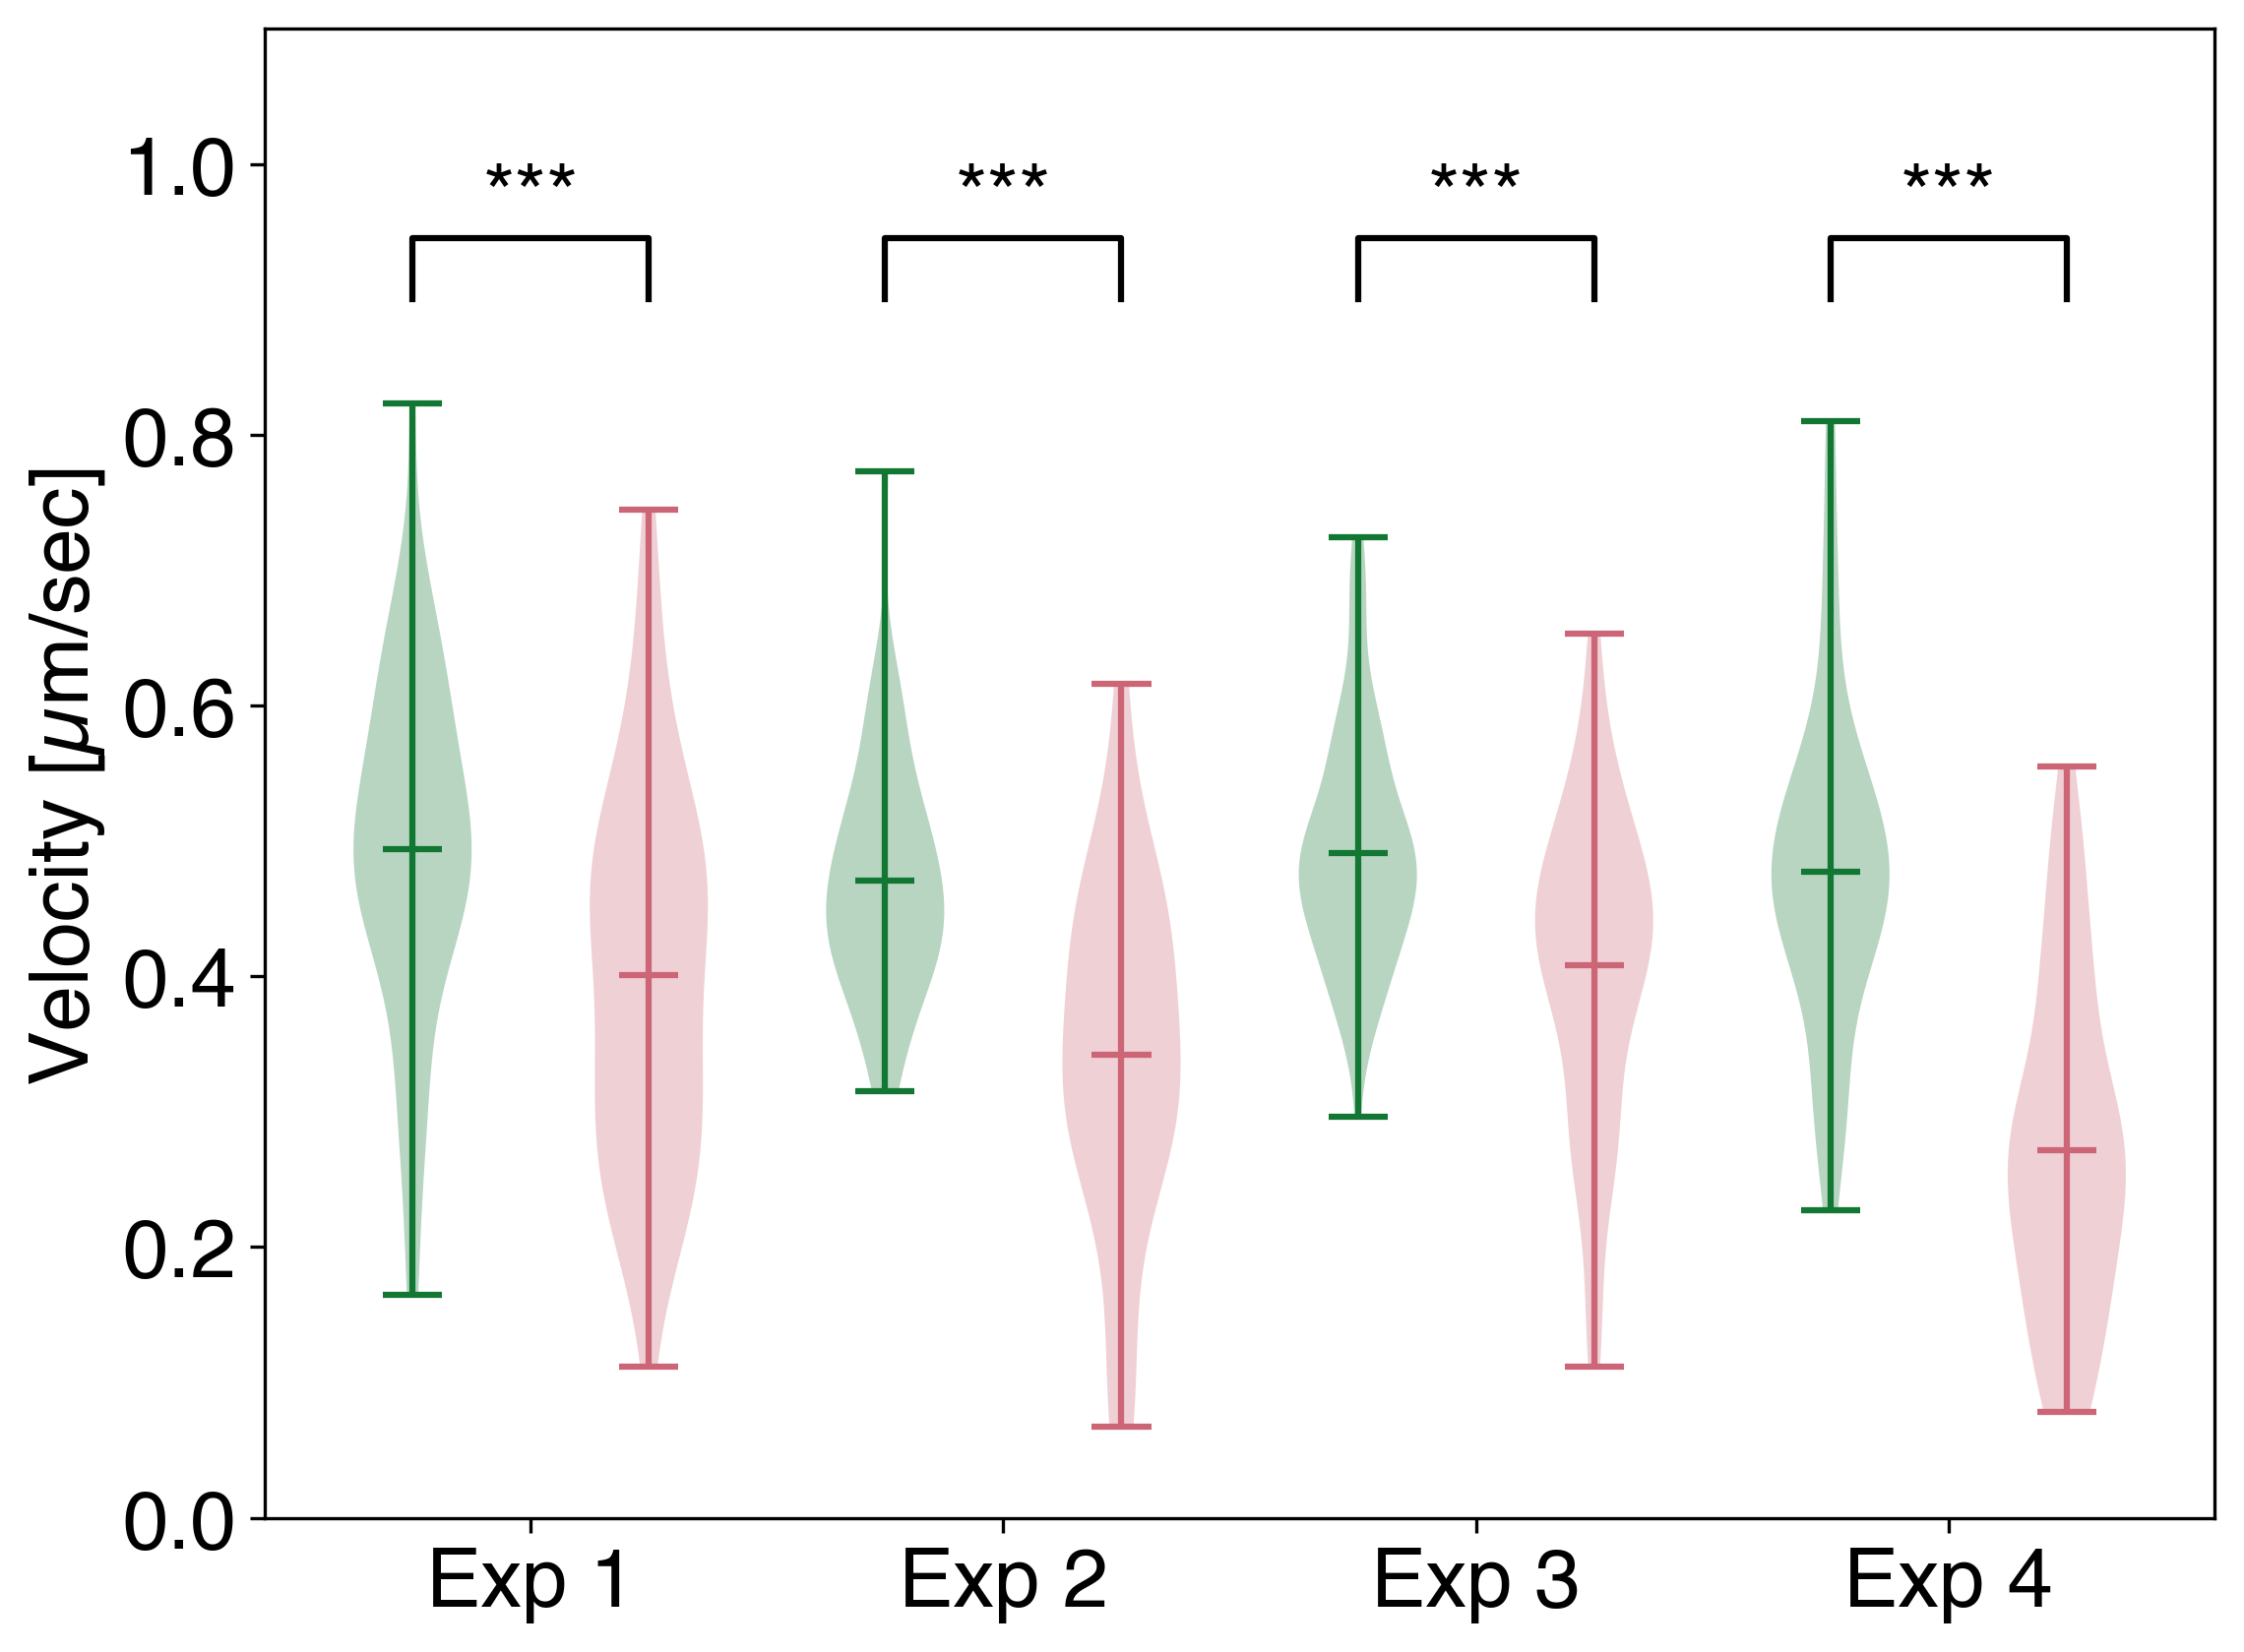

In [8]:
statics03_1, p_value03_1, sig03_1 = ttest(MC03_1[0], MC03_1[1])
statics03_2, p_value03_2, sig03_2 = ttest(MC03_2[0], MC03_2[1])
statics03_3, p_value03_3, sig03_3 = ttest(MC03_3[0], MC03_3[1])
statics03_4, p_value03_4, sig03_4 = ttest(MC03_4[0], MC03_4[1])

fig, ax = plt.subplots()

violin(MC03_1[0], ax, positions=1, color=style_colors[3])
violin(MC03_1[1], ax, positions=2, color=style_colors[0])
violin(MC03_2[0], ax, positions=3, color=style_colors[3])
violin(MC03_2[1], ax, positions=4, color=style_colors[0])
violin(MC03_3[0], ax, positions=5, color=style_colors[3])
violin(MC03_3[1], ax, positions=6, color=style_colors[0])
violin(MC03_4[0], ax, positions=7, color=style_colors[3])
violin(MC03_4[1], ax, positions=8, color=style_colors[0])

y_max = np.max(np.concatenate(MC03_1))
y = 0.9

h = y * 0.05

y_l = [y, y + h, y + h, y]

ax.plot([1, 1, 2, 2], y_l, lw=1.5, c='black')
ax.text(1.5, y + h, sig03_1, ha='center', va='bottom', color='black')

ax.plot([3, 3, 4, 4], y_l, lw=1.5, c='black')
ax.text(3.5, y + h, sig03_2, ha='center', va='bottom', color='black')

ax.plot([5, 5, 6, 6], y_l, lw=1.5, c='black')
ax.text(5.5, y + h, sig03_3, ha='center', va='bottom', color='black')

ax.plot([7, 7, 8, 8], y_l, lw=1.5, c='black')
ax.text(7.5, y + h, sig03_4, ha='center', va='bottom', color='black')

ax.set_ylabel('Velocity [µm/sec]')
ax.set_xticks([1.5, 3.5, 5.5, 7.5])
ax.set_xticklabels(['Exp 1', 'Exp 2', 'Exp 3', 'Exp 4'])
ax.set_ylim(0, 1.1)

In [9]:
fig.savefig(f"{save_folder}/MC03.png", bbox_inches='tight')
fig.savefig(f"{save_folder}/MC03.pdf", bbox_inches='tight')

Text(0.5, 1.0, 'MC 0.3%')

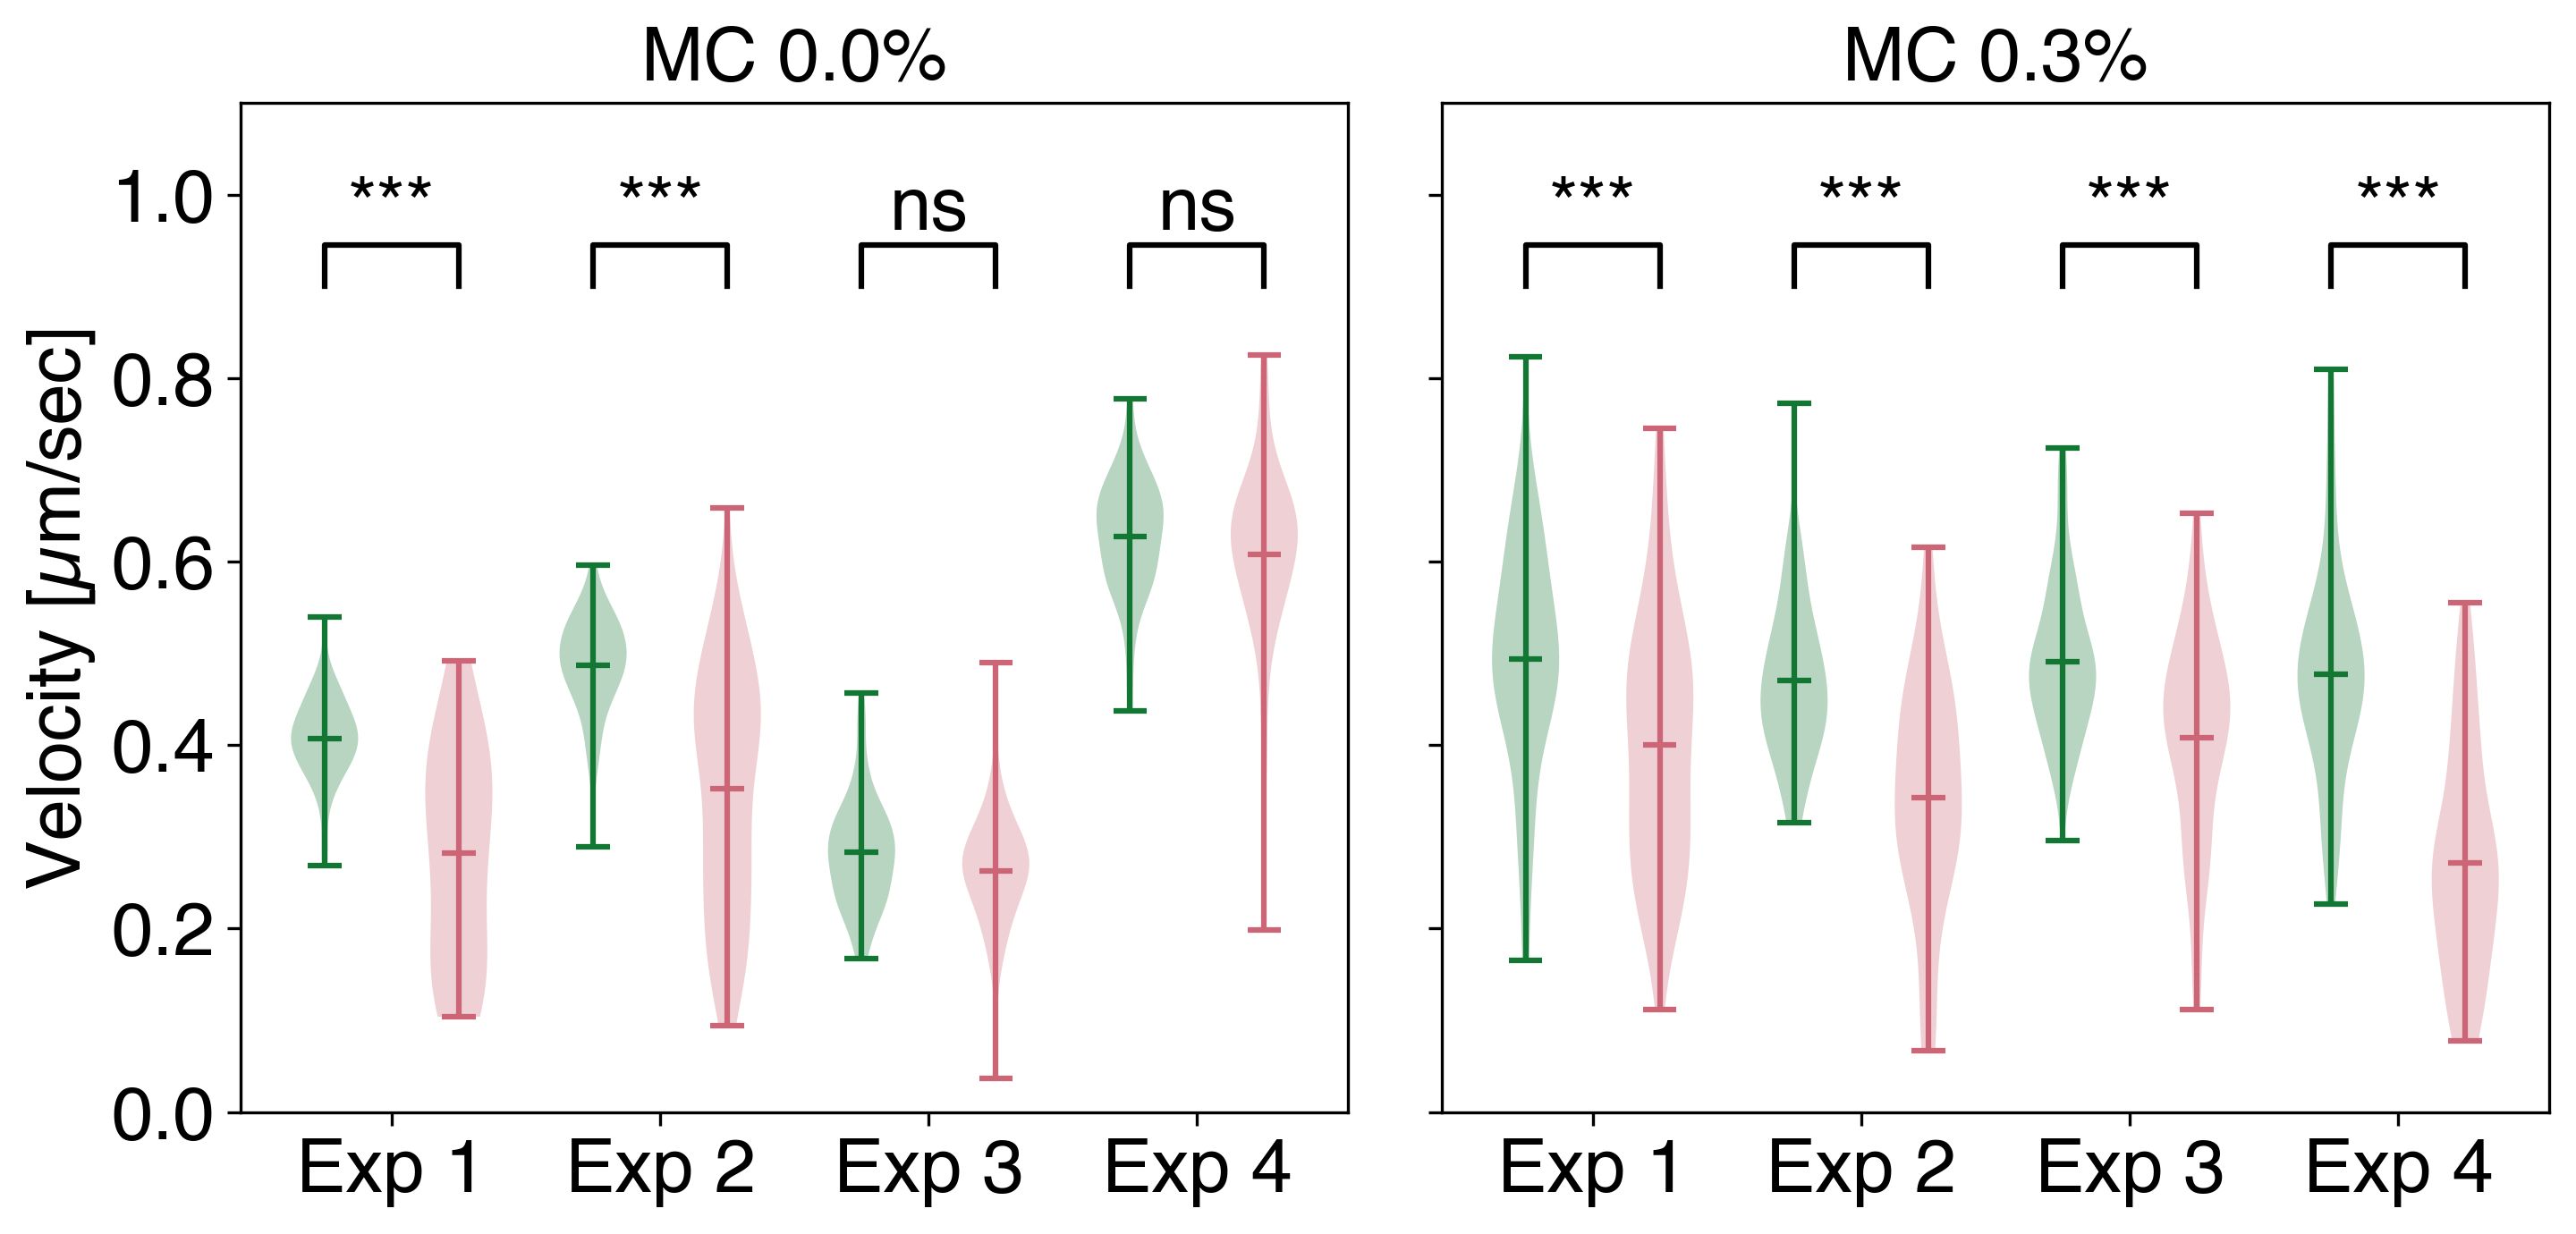

In [10]:
statics00_1, p_value00_1, sig00_1 = ttest(MC00_1[0], MC00_1[1])
statics00_2, p_value00_2, sig00_2 = ttest(MC00_2[0], MC00_2[1])
statics00_3, p_value00_3, sig00_3 = ttest(MC00_3[0], MC00_3[1])
statics00_4, p_value00_4, sig00_4 = ttest(MC00_4[0], MC00_4[1])

statics_12, p_value_12, sig_12 = ttest(MC00_2[0], MC00_1[0])

fig, ax = plt.subplots(1,2, figsize = (10,5))

violin(MC00_1[0], ax[0], positions=1, color=style_colors[3])
violin(MC00_1[1], ax[0], positions=2, color=style_colors[0])
violin(MC00_2[0], ax[0], positions=3, color=style_colors[3])
violin(MC00_2[1], ax[0], positions=4, color=style_colors[0])
violin(MC00_3[0], ax[0], positions=5, color=style_colors[3])
violin(MC00_3[1], ax[0], positions=6, color=style_colors[0])
violin(MC00_4[0], ax[0], positions=7, color=style_colors[3])
violin(MC00_4[1], ax[0], positions=8, color=style_colors[0])

y = 0.9

h = y * 0.05

y_l = [y, y + h, y + h, y]

ax[0].plot([1, 1, 2, 2], y_l, lw=1.5, c='black')
ax[0].text(1.5, y + h, sig00_1, ha='center', va='bottom', color='black')

ax[0].plot([3, 3, 4, 4], y_l, lw=1.5, c='black')
ax[0].text(3.5, y + h, sig00_2, ha='center', va='bottom', color='black')

ax[0].plot([5, 5, 6, 6], y_l, lw=1.5, c='black')
ax[0].text(5.5, y + h, sig00_3, ha='center', va='bottom', color='black')

ax[0].plot([7, 7, 8, 8], y_l, lw=1.5, c='black')
ax[0].text(7.5, y + h, sig00_4, ha='center', va='bottom', color='black')

ax[0].set_ylabel('Velocity [µm/sec]')
ax[0].set_xticks([1.5, 3.5, 5.5, 7.5])
ax[0].set_xticklabels(['Exp 1', 'Exp 2', 'Exp 3', 'Exp 4'])
ax[0].set_ylim(0, 1.1)
ax[0].set_title('MC 0.0%')


statics03_1, p_value03_1, sig03_1 = ttest(MC03_1[0], MC03_1[1])
statics03_2, p_value03_2, sig03_2 = ttest(MC03_2[0], MC03_2[1])
statics03_3, p_value03_3, sig03_3 = ttest(MC03_3[0], MC03_3[1])
statics03_4, p_value03_4, sig03_4 = ttest(MC03_4[0], MC03_4[1])

violin(MC03_1[0], ax[1], positions=1, color=style_colors[3])
violin(MC03_1[1], ax[1], positions=2, color=style_colors[0])
violin(MC03_2[0], ax[1], positions=3, color=style_colors[3])
violin(MC03_2[1], ax[1], positions=4, color=style_colors[0])
violin(MC03_3[0], ax[1], positions=5, color=style_colors[3])
violin(MC03_3[1], ax[1], positions=6, color=style_colors[0])
violin(MC03_4[0], ax[1], positions=7, color=style_colors[3])
violin(MC03_4[1], ax[1], positions=8, color=style_colors[0])

y = 0.9

h = y * 0.05

y_l = [y, y + h, y + h, y]

ax[1].plot([1, 1, 2, 2], y_l, lw=1.5, c='black')
ax[1].text(1.5, y + h, sig03_1, ha='center', va='bottom', color='black')

ax[1].plot([3, 3, 4, 4], y_l, lw=1.5, c='black')
ax[1].text(3.5, y + h, sig03_2, ha='center', va='bottom', color='black')

ax[1].plot([5, 5, 6, 6], y_l, lw=1.5, c='black')
ax[1].text(5.5, y + h, sig03_3, ha='center', va='bottom', color='black')

ax[1].plot([7, 7, 8, 8], y_l, lw=1.5, c='black')
ax[1].text(7.5, y + h, sig03_4, ha='center', va='bottom', color='black')

ax[1].set_xticks([1.5, 3.5, 5.5, 7.5])
ax[1].set_xticklabels(['Exp 1', 'Exp 2', 'Exp 3', 'Exp 4'])
ax[1].set_ylim(0, 1.1)
ax[1].tick_params(labelleft=False)
ax[1].set_title('MC 0.3%')

In [11]:
fig.savefig(f"{save_folder}/comparison.png", bbox_inches='tight')
fig.savefig(f"{save_folder}/comparison.pdf", bbox_inches='tight')